In [1]:
!pip install scipy

In [2]:
import pandas as pd

In [3]:
from google.colab import drive
import pandas as pd

# 1. Montage du drive
drive.mount('/content/drive')

# 2. Lecture du fichier (chemin exact basé sur ton image)
# Si ton dossier s'appelle bien "Colab Notebooks"
path = "/content/drive/MyDrive/Colab Notebooks/df_merged_clean.csv"
df = pd.read_csv(path)

print(f"✅ Fichier chargé ! Nombre de lignes : {len(df)}")

Mounted at /content/drive
✅ Fichier chargé ! Nombre de lignes : 565814


In [5]:
len(df)

565814

In [6]:
df.isna().sum()

,0
Unnamed: 0,0
overall,0
asin,0
reviewText,0
summary,46
language,0
year_x,0
month_x,0
day_of_week,0
main_cat,0


In [7]:
df['summary'] = df['summary'].fillna('')

In [8]:
# Filtrage des produits publiés à partir de 2010
df = df.loc[df['year_y']>2009,:]

In [9]:
len(df)

277981

In [10]:
df = df.dropna(subset=['brand'])

In [11]:
len(df)

277826

In [12]:
df.isna().sum()

,0
Unnamed: 0,0
overall,0
asin,0
reviewText,0
summary,0
language,0
year_x,0
month_x,0
day_of_week,0
main_cat,0


In [13]:
df['overall'].value_counts()

,count
overall,
2,56213
1,55689
4,55600
5,55271
3,55053


In [14]:
df['year_y'] = df['year_y'].astype('int')

In [15]:
from datetime import datetime

# Création d'une colonne date
def month_name_to_number(month_name):
    return datetime.strptime(month_name, "%B").month

df['month_y_num'] = df['month_y'].apply(month_name_to_number)
df.drop('month_y', axis=1, inplace=True)

df_rename = df.rename(columns={
    'year_y': 'year',
    'month_y_num': 'month',
    'day': 'day'
})

df_rename['date'] = pd.to_datetime(df_rename[['year', 'month', 'day']])
df_rename['day_of_week_y'] = df_rename['date'].dt.day_name()

In [16]:
df['day_of_week_y'] = df_rename['day_of_week_y']

In [17]:
df = df.iloc[:,1:]

In [18]:
df=df.drop(['language', 'day'],axis=1)

In [19]:
df=df.reset_index(drop=True)

In [20]:
df.head()

,overall,asin,reviewText,summary,year_x,month_x,day_of_week,main_cat,brand,year_y,presence_image,month_y_num,day_of_week_y
0,1,B004YI6N00,I first received this item with a broken speak...,This sucked terribly!,2013,3,Sunday,Home Audio & Theater,ECOXGEAR,2011,0,4,Wednesday
1,1,B0007NWL70,The cord broke the second time my son used it!,One Star,2016,4,Sunday,Home Audio & Theater,Kidz Gear,2012,0,9,Tuesday
2,1,B003TFEHYI,I can set my bluetooth enabled player right by...,Bluetooth is terrible,2013,7,Tuesday,Home Audio & Theater,Monster,2010,0,6,Monday
3,1,B004G603E2,It stopped working after two months...,One Star,2015,1,Sunday,All Electronics,Cooler Master,2010,0,12,Monday
4,1,B003YNS0W0,"These don't fit well, (to me) and seem to weak...",One Star,2015,4,Friday,All Electronics,Tripp Lite,2010,0,8,Saturday


In [21]:
df.columns

Index(['overall', 'asin', 'reviewText', 'summary', 'year_x', 'month_x',
       'day_of_week', 'main_cat', 'brand', 'year_y', 'presence_image',
       'month_y_num', 'day_of_week_y'],
      dtype='object')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277826 entries, 0 to 277825
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   overall         277826 non-null  int64 
 1   asin            277826 non-null  object
 2   reviewText      277826 non-null  object
 3   summary         277826 non-null  object
 4   year_x          277826 non-null  int64 
 5   month_x         277826 non-null  int64 
 6   day_of_week     277826 non-null  object
 7   main_cat        277826 non-null  object
 8   brand           277826 non-null  object
 9   year_y          277826 non-null  int64 
 10  presence_image  277826 non-null  int64 
 11  month_y_num     277826 non-null  int64 
 12  day_of_week_y   277826 non-null  object
dtypes: int64(6), object(7)
memory usage: 27.6+ MB


## Feature Engineering

Séparation du jeu de données en un jeu d'entraînement et de test

In [23]:
from sklearn.model_selection import train_test_split

# Supposons que tu as :
X = df.drop(columns=['overall'])  # Variables explicatives (features)
y = df['overall']                # Variable cible

# Séparation : 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # proportion de l'ensemble de test
    random_state=42,      # pour reproductibilité
)

In [24]:
y_train.to_pickle('y_train.pickle')
y_test.to_pickle('y_test.pickle')

### Encodage des variables catégorielles textuelles

Variables nominales

In [ ]:
### Encodage des variables catégorielles textuelles

In [25]:
df.columns

Index(['overall', 'asin', 'reviewText', 'summary', 'year_x', 'month_x',
       'day_of_week', 'main_cat', 'brand', 'year_y', 'presence_image',
       'month_y_num', 'day_of_week_y'],
      dtype='object')

In [26]:
df['main_cat'].nunique()

19

In [27]:
df['brand'].nunique()

3732

In [28]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

X_train['main_cat'] = X_train['main_cat'].astype(str)
X_test['main_cat'] = X_test['main_cat'].astype(str)

# ONE-HOT ENCODING pour main_cat
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype='int')
X_train_main_cat = ohe.fit_transform(X_train[['main_cat']])
X_test_main_cat = ohe.transform(X_test[['main_cat']])
main_cat_cols = ohe.get_feature_names_out(['main_cat'])

X_train_main_cat_df = pd.DataFrame(X_train_main_cat, columns=main_cat_cols, index=X_train.index)
X_test_main_cat_df = pd.DataFrame(X_test_main_cat, columns=main_cat_cols, index=X_test.index)

# FREQUENCY ENCODING pour brand
# Calcul de la fréquence de chaque catégorie
brand_freq = X_train['brand'].value_counts(normalize=True)
X_train['brand_freq'] = X_train['brand'].map(brand_freq)
X_test['brand_freq'] = X_test['brand'].map(brand_freq).fillna(0)

In [29]:
brand_freq

,proportion
brand,
Logitech,0.039449
Sony,0.025385
SanDisk,0.019117
AmazonBasics,0.018235
Asus,0.018096
...,...
Miles Kimball,0.000004
Autotrol,0.000004
MyGica,0.000004


Variables ordinales

In [30]:
df['day_of_week'].nunique()

7

In [31]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.6 MB/s eta 0:00:00


In [32]:
# ORDINAL ENCODING pour day_of_week

import category_encoders as ce

jours_ordre = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ordinal_enc = ce.OrdinalEncoder(cols='day_of_week')
ordinal_enc_y = ce.OrdinalEncoder(cols='day_of_week_y')

# Application de l'encodage Ordinal sur les données
X_train['day_of_week_ord'] = ordinal_enc.fit_transform(X_train[['day_of_week']])
X_test['day_of_week_ord'] = ordinal_enc.transform(X_test[['day_of_week']])

# Application de l'encodage Ordinal sur les données
#X_train['day_of_week_y_ord'] = ordinal_enc_y.fit_transform(X_train[['day_of_week_y']])
#X_test['day_of_week_y_ord'] = ordinal_enc_y.transform(X_test[['day_of_week_y']])

In [33]:
X_train.columns

Index(['asin', 'reviewText', 'summary', 'year_x', 'month_x', 'day_of_week',
       'main_cat', 'brand', 'year_y', 'presence_image', 'month_y_num',
       'day_of_week_y', 'brand_freq', 'day_of_week_ord'],
      dtype='object')

In [34]:
# On retire les colonnes d'origine encodées
X_train_encoded = X_train.drop(columns=['main_cat', 'day_of_week', 'day_of_week_y'])
X_test_encoded = X_test.drop(columns=['main_cat', 'day_of_week', 'day_of_week_y'])

X_train_encoded = X_train.drop(columns=['main_cat', 'day_of_week'])
X_test_encoded = X_test.drop(columns=['main_cat', 'day_of_week'])

# Puis on ajoute les nouvelles colonnes encodées
X_train_encoded = pd.concat([X_train_encoded, X_train_main_cat_df], axis=1)
X_test_encoded = pd.concat([X_test_encoded, X_test_main_cat_df], axis=1)

In [35]:
X_train_encoded.drop('brand', axis=1, inplace=True)

In [36]:
X_test_encoded.drop('brand', axis=1, inplace=True)

In [37]:
X_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222260 entries, 165565 to 121958
Data columns (total 30 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   asin                                   222260 non-null  object 
 1   reviewText                             222260 non-null  object 
 2   summary                                222260 non-null  object 
 3   year_x                                 222260 non-null  int64  
 4   month_x                                222260 non-null  int64  
 5   year_y                                 222260 non-null  int64  
 6   presence_image                         222260 non-null  int64  
 7   month_y_num                            222260 non-null  int64  
 8   day_of_week_y                          222260 non-null  object 
 9   brand_freq                             222260 non-null  float64
 10  day_of_week_ord                        222260 non-null  

## Text Mining : vectorisation des colonnes de texte

In [38]:
# 2. Fusionner les textes
X_train_encoded['text'] = X_train_encoded['reviewText'] + " " + X_train_encoded['summary']
X_test_encoded['text'] = X_test_encoded['reviewText'] + " " + X_test_encoded['summary']

Normalisation

In [39]:
X_train_encoded['text'] = X_train_encoded['text'].str.lower()
X_test_encoded['text'] = X_test_encoded['text'].str.lower()

Suppression des chiffres et ponctuation dans le texte

In [40]:
import re
# Filtrage de la ponctuation (. , .., ..., )
X_train_encoded['text'] = X_train_encoded['text'].apply(lambda x: re.sub(r"\.+", '', x))
X_test_encoded['text'] = X_test_encoded['text'].apply(lambda x: re.sub(r"\.+", '', x))

X_train_encoded['text'] = X_train_encoded['text'].apply(lambda x: re.sub(r"/", ' ', x))
X_test_encoded['text'] = X_test_encoded['text'].apply(lambda x: re.sub(r"/", ' ', x))


# Filtrage des chiffres
X_train_encoded['text']= X_train_encoded['text'].apply(lambda x: re.sub(r"[0-9]+", '', x))
X_test_encoded['text']= X_test_encoded['text'].apply(lambda x: re.sub(r"[0-9]+", '', x))

In [41]:
X_test_encoded['text']

,text
66818,well i really wanted to like this product as i...
69223,i have tried using this device several times w...
16543,dirties way too easilty and does not fit snug ...
115311,good sound and decent fit i wish they went a ...
269785,this adapter works great for me as my original...
...,...
269052,great and excellent i'm very confortable with ...
110021,bought in march to replace one that died after...
27576,i thought it sounded to good to be true with t...
105524,keeps disconnecting ll the time and the usb sh...


Tokenisation

In [42]:
# Tokenisation
from nltk.tokenize import word_tokenize
import nltk
import tqdm
from tqdm import tqdm

tqdm.pandas()
nltk.download('punkt_tab')
X_train_encoded['text_tokenized'] = X_train_encoded['text'].progress_apply(lambda x: word_tokenize(x, language='english'))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
100%|██████████| 222260/222260 [01:49<00:00, 2032.64it/s]


In [43]:
tqdm.pandas()
X_test_encoded['text_tokenized'] = X_test_encoded['text'].progress_apply(lambda x: word_tokenize(x, language='english'))

100%|██████████| 55566/55566 [00:27<00:00, 1994.06it/s]


In [44]:
X_test_encoded['text_tokenized'].head(50)

,text_tokenized
66818,"[well, i, really, wanted, to, like, this, prod..."
69223,"[i, have, tried, using, this, device, several,..."
16543,"[dirties, way, too, easilty, and, does, not, f..."
115311,"[good, sound, and, decent, fit, i, wish, they,..."
269785,"[this, adapter, works, great, for, me, as, my,..."
63194,"[i, received, the, powerpod, for, christmas, ,..."
146316,"[too, light, could, be, better, to, protect, y..."
50454,"[actually, ,, i, got, it, for, free, (, signif..."
137445,"[works, ok, as, long, as, the, inputs, are, ei..."
194432,"[great, price, !, ca, n't, beat, the, per, foo..."


Filtrage des Stop Words

In [45]:
# Importer stopwords de la classe nltk.corpus
from nltk.corpus import stopwords
nltk.download('stopwords')
# Initialiser la variable des mots vides
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [46]:
print(stop_words)

{"you'd", 'once', 'down', 'further', 'wouldn', "needn't", "isn't", 'than', 'ma', 'ours', "i'm", "i've", 'should', "you've", "don't", 'to', 'as', 'at', 'both', 'do', "mustn't", "she'll", 'was', 'now', 'below', 'through', 'yourself', "couldn't", 'own', 'so', 'our', 'yourselves', 'my', 'don', 'doing', 'haven', 'aren', 'd', 'mightn', 've', "aren't", 'which', 'then', 'did', 'theirs', 'into', 'other', 'here', 'under', 'more', 'will', "it's", 'any', 'him', 'does', 'weren', 'but', 'why', 'against', 'o', "she'd", 'them', 'when', "didn't", 'having', "i'll", 'i', 'until', 'with', 'between', 'be', "doesn't", 'isn', "he'd", 'not', 'himself', 'couldn', 'can', 'some', 'were', 'what', 'where', 'she', "she's", 'he', 'that', 'won', 'because', 'who', 'been', "shouldn't", 'above', "that'll", 're', 'shan', 'y', 'me', 'such', 'yours', 'we', "weren't", 'her', 'its', "you'll", 'a', 'am', 'and', 'each', 'has', 't', 'herself', 'off', 'all', 'his', "they'll", 'an', "hasn't", "mightn't", 'how', 'myself', 'ourselv

In [47]:
# Ajout de la ponctuation dans les stopwords
stop_words.update([",", ".", "``", "@", "*", "(", ")", "[","]", "...", "-", "_", ">", "<", ":", "/", "//", "///", "=", "--", "©", "~", ";", "\\", "\\\\", '"', "'","''", '""' "'m", "'ve", "n't","!","?", "'re", "rd", "'s", "%"])

In [48]:
def stop_words_filtering(mots) :
    tokens = []
    for mot in mots:
        if mot not in stop_words:
            tokens.append(mot)
    return tokens

In [49]:
# Filtrage des stop words
tqdm.pandas()
X_train_encoded['text_tokenized'] = X_train_encoded['text_tokenized'].progress_apply(stop_words_filtering)
X_test_encoded['text_tokenized'] = X_test_encoded['text_tokenized'].progress_apply(stop_words_filtering)

100%|██████████| 55566/55566 [00:01<00:00, 33444.34it/s]


In [50]:
X_test_encoded['text_tokenized'].tail(50)

,text_tokenized
203066,"[needed, four, stars]"
96423,"[bought, four, gb, sticks, installed, computer..."
73899,"[suppose, quite, exact, made, light, metal, ev..."
63457,"[mm, blue, led, fan, nice, look, clear, blades..."
1842,"[maybe, 'm, professional, struggling, lens, pi..."
134440,"[one, pair, hold, charge, three, stars]"
16137,"[got, hard, disc, replacement, crashed, drive,..."
270782,"[good, product, five, stars]"
250360,"[much, solid, expected, price, would, definite..."
102223,"[decent, mouse, fits, naturally, hand, horribl..."


In [51]:
# Lemmatisation
### Importer le package nécessaire
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

# Initialiser un lemmatiseur
wordnet_lemmatizer = WordNetLemmatizer()

def lemmatisation(mots) :
    sortie = []
    for string in mots :
        radical = wordnet_lemmatizer.lemmatize(string)
        if (radical not in sortie) : sortie.append(radical)
    return sortie

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [52]:
tqdm.pandas()
X_train_encoded['lemmes'] = X_train_encoded['text_tokenized'].progress_apply(lemmatisation)
X_test_encoded['lemmes'] = X_test_encoded['text_tokenized'].progress_apply(lemmatisation)


100%|██████████| 55566/55566 [00:23<00:00, 2390.66it/s]


In [53]:
X_test_encoded['lemmes'].head()
X_train_encoded['lemmes'].head()

,lemmes
165565,"[probably, would, order, againi, like, materia..."
102367,"[worked, stopped, working, year, later, failed]"
130780,"[way, see, two, problem, adapter, one, apple, ..."
60400,"[radio, stopped, working, hour, use, returned,..."
240265,"[adapter, broken, computer, dropped, corner, s..."


In [54]:
for i in X_train_encoded.index :
    X_train_encoded.loc[i, 'lemmes'] = ' '.join(X_train_encoded.loc[i, 'lemmes'])
X_train_encoded['lemmes'].head()

,lemmes
165565,probably would order againi like material insi...
102367,worked stopped working year later failed
130780,way see two problem adapter one apple fault al...
60400,radio stopped working hour use returned amazon...
240265,adapter broken computer dropped corner survive...


In [55]:
for i in X_test_encoded.index :
    X_test_encoded.loc[i, 'lemmes'] = ' '.join(X_test_encoded.loc[i, 'lemmes'])
X_test_encoded['lemmes'].head()

,lemmes
66818,well really wanted like product super easy set...
69223,tried using device several time without succes...
16543,dirties way easilty fit snug prop ipad type sl...
115311,good sound decent fit wish went little ear thr...
269785,adapter work great original audio port broken ...


In [56]:
X_train_encoded.to_pickle('X_train_lemmes.pickle')
X_test_encoded.to_pickle('X_test_lemmes.pickle')

In [57]:
len(y_test)

55566

Rééquilibrage des classes regroupées

In [ ]:
# Nous allons essayer d'échantillonner un plus grand nombre d'avis à 3 étoiles pour rééquilibrer les classes.

In [58]:
import pandas as pd
import numpy as np

In [59]:
X_train = pd.read_pickle("X_train_lemmes.pickle")
X_test = pd.read_pickle("X_test_lemmes.pickle")

In [60]:
# Regrouper les données
# Regrouper les notes
def regrouper_notes(y):
    """
    Regroupe les notes :
    - 1, 2 -> 1 (négatif)
    - 3    -> 2 (neutre)
    - 4, 5 -> 3 (positif)
    """
    return y.replace({1: 1, 2: 1, 3: 2, 4: 3, 5: 3})

# Application
y_train_grouped = regrouper_notes(y_train)
y_test_grouped = regrouper_notes(y_test)

In [61]:
# 3. Fonction pour équilibrer un ensemble via index
def equilibrer_par_index(x_df, y_series_grouped):
    # Obtenir les index par classe
    classes = y_series_grouped.unique()
    series_by_class = [y_series_grouped[y_series_grouped == c] for c in classes]

    # Taille minimale pour équilibrer
    min_count = min(len(s) for s in series_by_class)

    # Sous-échantillonnage équilibré
    sampled_idx = [s.sample(n=min_count, random_state=42).index for s in series_by_class]
    final_idx = pd.Index(np.concatenate(sampled_idx)).sort_values()

    # Appliquer aux X et Y
    x_balanced = x_df.loc[final_idx]
    y_balanced = y_series_grouped.loc[final_idx]

    return x_balanced, y_balanced

In [62]:
# 4. Appliquer sur train et test
x_train_bal, y_train_bal = equilibrer_par_index(X_train, y_train_grouped)
x_test_bal, y_test_bal = equilibrer_par_index(X_test, y_test_grouped)

In [63]:
# 5. Vérification (optionnelle)
print("Train équilibré :", y_train_bal.value_counts())
print("Test équilibré :", y_test_bal.value_counts())

Train équilibré : overall
1    44037
2    44037
3    44037
Name: count, dtype: int64
Test équilibré : overall
1    11016
2    11016
3    11016
Name: count, dtype: int64


In [64]:
y_train_grouped.to_pickle('y_train_grouped.pickle')
y_test_grouped.to_pickle('y_test_grouped.pickle')

#### ESSAI DE CLASSIFICATION DE TEXTE AVEC UN RESEAU CNN à 1D

In [ ]:
## ESSAI DE CLASSIFICATION DE TEXTE AVEC UN RESEAU CNN à 1D

In [65]:
# Loading Data
vocab_size = 10000
max_length = 500
x_train = x_train_bal['lemmes']
y_train = y_train_bal
x_test = x_test_bal['lemmes']
y_test = y_test_bal

In [66]:
x_test.shape

(33048,)

In [67]:
y_test.shape

(33048,)

In [68]:
y_train

,overall
2,1
7,1
9,1
13,1
15,1
...,...
277815,3
277817,3
277818,3
277823,3


In [69]:
# --- AJOUTE CES IMPORTS ---
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing import sequence
# Paramètres
vocab_size = 10000
max_length = 50  # longueur max des séquences

# Initialisation
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(x_train)

# Transformation des textes en séquences de tokens
x_train = tokenizer.texts_to_sequences(x_train)
x_test = tokenizer.texts_to_sequences(x_test)

x_train = sequence.pad_sequences(x_train, maxlen=max_length)
x_test = sequence.pad_sequences(x_test, maxlen=max_length)

In [70]:
x_test.shape
x_train.shape

(132111, 50)

In [71]:
len(x_train)

132111

In [74]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [76]:
# =============================================
# 🔥 SENTIMENT ANALYSIS - LSTM + GloVe (Version Optimisée)
# =============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import RMSprop

# =============================================
# 🔹 Chargement des embeddings GloVe
# =============================================

embeddings_index = {}
with open("/content/drive/MyDrive/Colab Notebooks/glove.6B.300d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = coefs

print(f"✅ {len(embeddings_index):,} mots chargés depuis GloVe.")


# =============================================
# 🔹 Construction de la matrice d’embedding
# =============================================

embedding_dim = 300
vocab_size = 20000  # 🔼 élargi pour capter plus de vocabulaire

word_index = tokenizer.word_index  # ⚠️ ton tokenizer existant
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():
    if i < vocab_size:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

print(f"✅ Matrice d'embedding créée : {embedding_matrix.shape}")

# =============================================
# 🔹 Définition du modèle optimisé
# =============================================

model = Sequential([
    Embedding(vocab_size,
              embedding_dim,
              weights=[embedding_matrix],
              trainable=True),  # 🔥 fine-tuning activé

    Bidirectional(LSTM(64, dropout=0.4, recurrent_dropout=0.2, return_sequences=True)),
    Bidirectional(LSTM(32, dropout=0.3)),

    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax')
])

# =============================================
# 🔹 Compilation avec RMSprop
# =============================================

model.compile(
    optimizer=RMSprop(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =============================================
# 🔹 Early Stopping intelligent
# =============================================

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# =============================================
# 🔹 Entraînement
# =============================================

history = model.fit(
    x_train,
    y_train - 1,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

# =============================================
# 🔹 Visualisation des performances
# =============================================

plt.figure(figsize=(10,6))
plt.plot(history.history['accuracy'], label='Accuracy entraînement', linestyle='-')
plt.plot(history.history['val_accuracy'], label='Accuracy validation', linestyle='--')
plt.title("Courbe d'apprentissage - LSTM + GloVe Optimisé")
plt.xlabel("Épochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Loss entraînement', linestyle='-')
plt.plot(history.history['val_loss'], label='Loss validation', linestyle='--')
plt.title("Loss - Entraînement vs Validation")
plt.xlabel("Épochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# =============================================
# 🔹 Évaluation du modèle
# =============================================

y_pred = np.argmax(model.predict(x_test), axis=1)

print("\n🔹 Rapport de classification :")
print(classification_report(y_test - 1, y_pred, digits=3))

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test - 1, y_pred),
            annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion - LSTM + GloVe Optimisé")
plt.xlabel("Prédictions")
plt.ylabel("Véritables classes")
plt.show()

✅ 400,000 mots chargés depuis GloVe.
✅ Matrice d'embedding créée : (20000, 300)
Epoch 1/20
1652/1652 ━━━━━━━━━━━━━━━━━━━━ 816s 483ms/step - accuracy: 0.5778 - loss: 0.8705 - val_accuracy: 0.6971 - val_loss: 0.7073
Epoch 2/20
1652/1652 ━━━━━━━━━━━━━━━━━━━━ 789s 477ms/step - accuracy: 0.6698 - loss: 0.7166 - val_accuracy: 0.4772 - val_loss: 1.2725
Epoch 3/20
 254/1652 ━━━━━━━━━━━━━━━━━━━━ 13:28 578ms/step - accuracy: 0.6812 - loss: 0.6814

KeyboardInterrupt: 

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 86.387892 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 977617
[LightGBM] [Info] Number of data points in the train set: 132111, number of used features: 19999
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[691]	valid_0's multi_logloss: 0.632546


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



🔹 Rapport de classification :
              precision    recall  f1-score   support

           0      0.743     0.753     0.748     11016
           1      0.628     0.607     0.617     11016
           2      0.770     0.787     0.779     11016

    accuracy                          0.715     33048
   macro avg      0.714     0.715     0.715     33048
weighted avg      0.714     0.715     0.715     33048



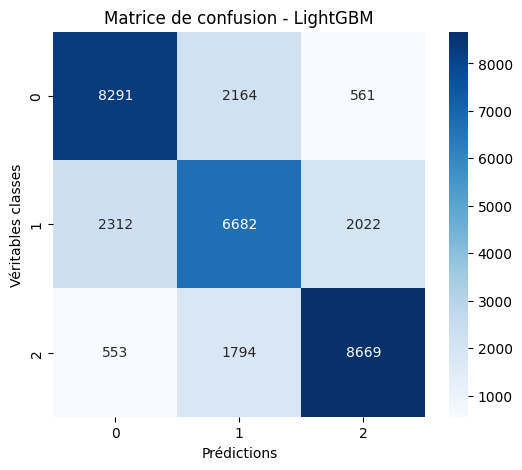

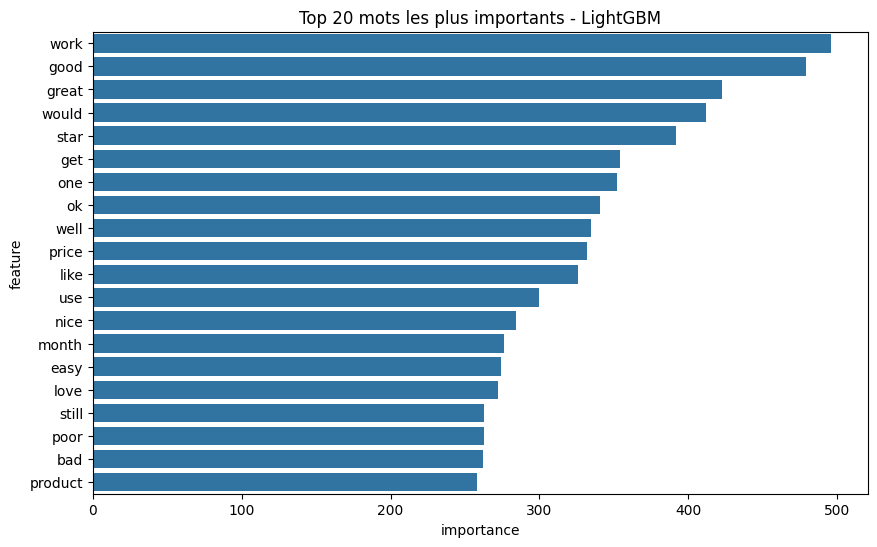

In [77]:

# ⚡ SENTIMENT ANALYSIS - LightGBM (Baseline)
# =============================================

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# =============================================
# 🔹 Préparation des données texte
# =============================================

# ⚠️ Remplace ces lignes par ton propre jeu de données :
# X_train_encoded['text'] = tes phrases
# X_train_encoded['label'] = tes classes (1, 2, 3 par ex.)
# Exemple :
# X_train_encoded = pd.DataFrame({'text': x_text, 'label': y})


# =============================================
# 🔹 TF-IDF vectorisation (représentation des textes)
# =============================================# =============================================
x_train_bal, y_train_bal = equilibrer_par_index(X_train, y_train_grouped)
x_test_bal, y_test_bal = equilibrer_par_index(X_test, y_test_grouped)

y_train = y_train_bal - 1
y_test = y_test_bal - 1
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),  # 🔥 capture aussi les paires de mots
)

X_train_tfidf = tfidf.fit_transform(x_train_bal['lemmes'])
X_test_tfidf = tfidf.transform(x_test_bal['lemmes'])

# =============================================
# 🔹 Configuration du modèle LightGBM
# =============================================

params = {
    'objective': 'multiclass',
    'num_class': 3,  # ⚠️ adapte selon ton nb de classes
    'learning_rate': 0.05,
    'num_leaves': 64,
    'max_depth': -1,
    'n_estimators': 1000,
    'colsample_bytree': 0.8,
    'subsample': 0.8,
    'random_state': 42,
    'metric': 'multi_logloss'
}

model = lgb.LGBMClassifier(**params)

# =============================================
# 🔹 Entraînement avec early stopping
# =============================================

model.fit(
    X_train_tfidf, y_train,
    eval_set=[(X_test_tfidf, y_test)],
    eval_metric='multi_logloss',
    callbacks=[lgb.early_stopping(50)]
)

# =============================================
# 🔹 Prédictions et évaluation
# =============================================

y_pred = model.predict(X_test_tfidf)

print("\n🔹 Rapport de classification :")
print(classification_report(y_test, y_pred, digits=3))

# =============================================
# 🔹 Matrice de confusion
# =============================================

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion - LightGBM")
plt.xlabel("Prédictions")
plt.ylabel("Véritables classes")
plt.show()

# =============================================
# 🔹 Importance des features
# =============================================

importances = pd.DataFrame({
    'feature': tfidf.get_feature_names_out(),
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importances.head(20), x='importance', y='feature')
plt.title("Top 20 mots les plus importants - LightGBM")
plt.show()


In [78]:
# =============================================
# 🧠 SHAP - LightGBM (multiclasse) — stable fix for shape mismatch
# =============================================

import shap
import numpy as np

print("\n🔍 Initialisation du SHAP TreeExplainer...")
explainer = shap.TreeExplainer(model)


# Convertir en dense avant le calcul pour éviter des incompatibilités avec scipy sparse
X_sample_dense = X_sample.toarray()

print("⚙️ Calcul des valeurs SHAP multiclasse...")
shap_values = explainer.shap_values(X_sample_dense)

# SHAP peut renvoyer soit :
# - une liste de tableaux (un tableau par classe) de shape (n_samples, n_features)
# - un ndarray de shape (n_samples, n_features, n_classes)
# Normaliser dans le format liste de tableaux par classe pour être sûr.
if isinstance(shap_values, np.ndarray):
    if shap_values.ndim == 3:
        # (n_samples, n_features, n_classes) -> liste [ (n_samples, n_features) ... ]
        shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
    elif shap_values.ndim == 2:
        # binaire ou mono-classe -> garder tel quel dans une liste
        shap_values = [shap_values]
elif isinstance(shap_values, list):
    # déjà au bon format, rien à faire
    pass
else:
    raise ValueError(f"Format inattendu pour shap_values: type={type(shap_values)}, ndim={getattr(shap_values, 'ndim', None)}")

# Récupération des noms de features TF-IDF
feature_names = tfidf.get_feature_names_out()

# ===========================
# Visualisation par classe
# ===========================
class_names = ["Négatif", "Neutre", "Positif"]
selected_class = 1  # 0, 1 ou 2

print(f"\n✅ Affichage du summary plot SHAP pour la classe {selected_class} ({class_names[selected_class]})")

# Vérification des dimensions avant affichage (sécurité)
assert 0 <= selected_class < len(shap_values), "selected_class hors de portée pour shap_values"
assert shap_values[selected_class].shape == X_sample_dense.shape, (
    f"Mismatch shapes: shap {shap_values[selected_class].shape} vs X {X_sample_dense.shape}"
)


# Parcourir les classes et afficher un summary plot par classe
for i, cls in enumerate(class_names):
    print(f"\n✅ Affichage du summary plot SHAP pour la classe {i} ({cls})")
    plt.figure(figsize=(16, 12))
    shap.summary_plot(
        shap_values[i],            # Valeurs SHAP pour la classe (n_samples, n_features)
        X_sample_dense,            # Données d'entrée (n_samples, n_features)
        feature_names=feature_names,
        max_display=20,
        show=True
    )


🔍 Initialisation du SHAP TreeExplainer...


NameError: name 'X_sample' is not defined

In [79]:
import joblib

# 1. Sauvegarde du modèle entraîné
joblib.dump(model, 'trustpilot_lgbm_model.pkl')

# 2. Sauvegarde du vectoriseur (TRES IMPORTANT)
# Il contient le vocabulaire exact appris pendant l'entraînement
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("✅ Sauvegarde réussie !")
print("👉 Tu as maintenant deux nouveaux fichiers : 'trustpilot_lgbm_model.pkl' et 'tfidf_vectorizer.pkl'")
print("👉 Ce sont ces fichiers que tu devras mettre dans le dossier de ton application Streamlit.")

✅ Sauvegarde réussie !
👉 Tu as maintenant deux nouveaux fichiers : 'trustpilot_lgbm_model.pkl' et 'tfidf_vectorizer.pkl'
👉 Ce sont ces fichiers que tu devras mettre dans le dossier de ton application Streamlit.


In [80]:
import shutil
import os

drive_path = "/content/drive/MyDrive/Colab Notebooks/Trained_Models"

# Créer le dossier s'il n'existe pas
if not os.path.exists(drive_path):
    os.makedirs(drive_path)
    print(f"Dossier '{drive_path}' créé.")
else:
    print(f"Dossier '{drive_path}' existe déjà.")

# Copier les fichiers
shutil.copy('trustpilot_lgbm_model.pkl', drive_path)
shutil.copy('tfidf_vectorizer.pkl', drive_path)

print("✅ Fichiers copiés avec succès dans votre Google Drive !")
print(f"Vous pouvez les trouver ici : {drive_path}")

Dossier '/content/drive/MyDrive/Colab Notebooks/Trained_Models' créé.
✅ Fichiers copiés avec succès dans votre Google Drive !
Vous pouvez les trouver ici : /content/drive/MyDrive/Colab Notebooks/Trained_Models
